In [24]:
# Import
import torch
import torch.nn as nn
import numpy as np
from tqdm.notebook import trange, tqdm
import h5py
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg')
%matplotlib inline
import ecg_plot, pandas as pd
import sys, glob, h5py
import ecgprep
import os

# helper function
def exists(path):
    val = os.path.exists(path)
    if val:
        print(f'{path} already exits. Using cached. Delete it manually to recieve it again!')
    return val

Epoch  1: train - Loss: 1734.208993:  20%|█▉        | 57/287 [00:15<00:08, 27.77it/s]

The data is already in HDF5 (H5) format, hence the following is not needed:

In [2]:
##################################
# 3. Generate train
#if not exists('2-soa-model-ecg/exams_part0.hdf5'):
#    !python ../ecg-preprocessing/generate_h5.py --new_freq 400 --new_len 4096 --remove_baseline --remove_powerline 60 ../codesubset/train/RECORDS.txt exams_part0.hdf5
##################################

In [3]:
!pwd

/mimer/NOBACKUP/groups/naiss2024-5-153/Aditya/2-soa-ecg-model/ecg-age-prediction


In [4]:
%%time
PATH_TO_CSV = './data/code15-12l/exams.csv'
PATH_TO_H5 = './data/code15-12l/exams_part0.hdf5'
subsets = glob.glob('data/code15-12l/*.hdf5')[:5]
subsets

CPU times: user 1.16 ms, sys: 344 μs, total: 1.51 ms
Wall time: 10.1 ms


['data/code15-12l/exams_part1.hdf5',
 'data/code15-12l/exams_part0.hdf5',
 'data/code15-12l/exams_part2.hdf5',
 'data/code15-12l/exams_part3.hdf5',
 'data/code15-12l/exams_part4.hdf5']

## Description
The CODE-15% dataset is a part of the greater dataset, or the full dataset CODE. The full dataset has ECG exams of roughly 1.56M patients, which will be the future exploration of this thesis, which is large-scale distributed FL. CODE-15%, as the name suggests, is the 15% chunk of the full dataset, corresponding to ECG exams of around 233K patients. 

The dataset of CODE-15% is split across multiple zip files (17 of them), and each zip file is around 2.7GB (https://zenodo.org/records/4916206). Each zip file contains 20K training examples. For now, we focus on 4 of them.

For a very basic FL scenario, we now assume that each zip file represents a client, in a hypothetical FL training setup. They want to train a state-of-the-art model that conducts age prediction based on the ECG exams, and some other features (e.g. if the patient has been tested positive for certain health conditions).

## The process:
- Here, it is assumed that the data is already preprocessed.
- 4 clients are initially decided to be created, each having 20K training examples (one zip file = one client).
- We run the train function that the SOA age predictor model has, and we provide two paths:
   - \$H5PATH - the path to the ECG exam data
   - \$CSVPATH - the path of the CSV, that contains the patient info (which are additional features that are part of the model's prediction task e.g. isMale, death, and other collected metrics). It is also a matching file for knowing which patient's ECG exam is located in which ZIP file.
- The train-valid split: 20K training examples per client -- [ 16K training, 4K validation ] $\times$ 4 clients

## Hold-out (test) set: Sami-Trop Cohort
- This dataset is of a different group, and used for the very final testing after training and validation.
- Contains around 1.6K data points. https://zenodo.org/records/4905618

In [5]:
%%time
traces_ids = np.ones((5, 20001))
x = np.ones((5, 20001, 4096, 12))
for i, part in enumerate(subsets):
    print(len(traces_ids), x.shape)
    f = h5py.File(part, 'r')
    traces_ids[i] = np.array(f['exam_id'])
    x[i] = np.array(f['tracings']) ## WARNING: Very memory-intensive, can cause kernel to crash
    print("Done! At number --", i)

5 (5, 20001, 4096, 12)
Done! At number -- 0
5 (5, 20001, 4096, 12)
Done! At number -- 1
5 (5, 20001, 4096, 12)
Done! At number -- 2
5 (5, 20001, 4096, 12)
Done! At number -- 3
5 (5, 20001, 4096, 12)
Done! At number -- 4
CPU times: user 9.24 s, sys: 15.3 s, total: 24.5 s
Wall time: 41.4 s


In [6]:
df = pd.read_csv(PATH_TO_CSV)

In [7]:
df

,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file
0,1169160,38,True,40.160484,False,False,False,False,False,False,523632,False,2.098628,True,exams_part13.hdf5
1,2873686,73,True,67.059440,False,False,False,False,False,False,1724173,False,6.657529,False,exams_part13.hdf5
2,168405,67,True,79.621740,False,False,False,False,False,True,51421,False,4.282188,False,exams_part13.hdf5
3,271011,41,True,69.750260,False,False,False,False,False,False,1737282,False,4.038353,True,exams_part13.hdf5
4,384368,73,True,78.873460,False,False,False,False,False,False,331652,False,3.786298,False,exams_part13.hdf5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345774,1123951,33,True,35.893005,False,False,False,False,False,False,770553,False,2.189039,True,exams_part2.hdf5
345775,954704,73,False,68.169136,False,False,False,False,False,False,1044781,False,2.520546,False,exams_part2.hdf5
345776,589697,75,False,78.080810,False,False,False,False,False,False,1020589,False,3.304107,False,exams_part2.hdf5
345777,2780563,44,False,73.120636,False,False,False,False,False,False,178,False,7.339720,False,exams_part2.hdf5


In [37]:
#!rm model/history.csv

In [10]:
files_list = [item.replace('data/code15-12l/', '') for item in subsets]
for fil in files_list:
    df_0 = df.copy()
    df_0 = df_0[df_0['trace_file']==fil].dropna()
    df_0.to_csv(f'./data/code15-12l/{fil}.csv', index=False)

Epoch  0: train - Loss: 380.029894:   3%|▎         | 9/287 [01:09<00:11, 23.43it/s]t]

Namespace(epochs=10, seed=2, sample_freq=400, seq_length=4096, scale_multiplier=10, batch_size=32, lr=1e-05, patience=2, min_lr=1e-10, lr_factor=0.1, net_filter_size=[64, 128, 196, 256, 320], net_seq_lengh=[4096, 1024, 256, 64, 16], dropout_rate=0.4, kernel_size=17, folder='model/', traces_dset='tracings', ids_dset='', age_col='age', ids_col=None, cuda='1', n_valid=5000, path_to_traces='data/code15-12l/exams_part1.hdf5', path_to_csv='./data/code15-12l/exams_part0.hdf5.csv')
Building data loaders...
Done!
Define model...


Epoch  0: train - Loss: 380.029894:   3%|▎         | 9/287 [01:09<00:11, 23.43it/s]t]

Is there an existing trained model? - False
Done!
Define optimizer...
Done!
Define scheduler...
Done!
Training...


Epoch  0: train - Loss: 380.029894:   3%|▎         | 9/287 [01:24<00:11, 23.43it/s]t]/mimer/NOBACKUP/groups/naiss2024-5-153/Aditya/2-soa-ecg-model/ecg-age-prediction/train.py:242: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history = pd.concat([history, pd.DataFrame([{"epoch": ep, "train_loss": train_loss,


...

Epoch  0: train - Loss: 380.029894:   3%|▎         | 9/287 [05:06<00:11, 23.43it/s]/it]

Epoch  8: 	Train Loss 400.087467 	Train MSE 436.44907 	Train MAE 19.82728
		Valid Loss 390.885937 	Valid MSE 374.75943 	Valid MAE 16.85343 	Learning Rate 0.0000001	


Epoch  0: train - Loss: 380.029894:   3%|▎         | 9/287 [05:18<00:11, 23.43it/s]/it]

Epoch  9: 	Train Loss 401.919761 	Train MSE 320.94858 	Train MAE 16.90581
		Valid Loss 390.933497 	Valid MSE 374.36487 	Valid MAE 16.84409 	Learning Rate 0.0000001	
Done!


Epoch  0: train - Loss: 292.516418:   0%|          | 1/285 [04:45<22:30:58, 285.42s/it]


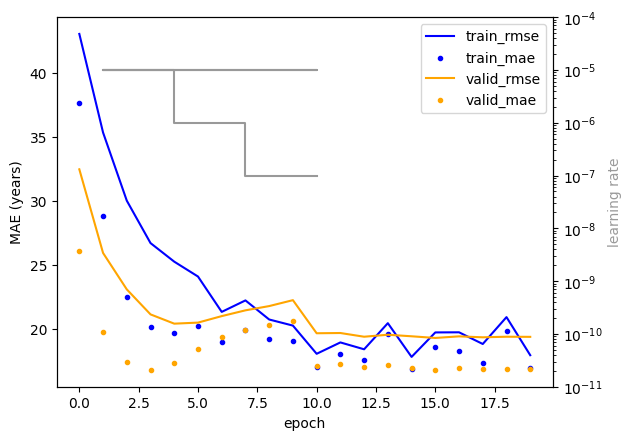

Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [04:44<00:10, 27.76it/s]

Namespace(epochs=10, seed=2, sample_freq=400, seq_length=4096, scale_multiplier=10, batch_size=32, lr=1e-05, patience=2, min_lr=1e-10, lr_factor=0.1, net_filter_size=[64, 128, 196, 256, 320], net_seq_lengh=[4096, 1024, 256, 64, 16], dropout_rate=0.4, kernel_size=17, folder='model/', traces_dset='tracings', ids_dset='', age_col='age', ids_col=None, cuda='1', n_valid=5000, path_to_traces='data/code15-12l/exams_part2.hdf5', path_to_csv='./data/code15-12l/exams_part2.hdf5.csv')
Building data loaders...
Done!
Define model...
Is there an existing trained model? - True
Done!
Define optimizer...
Done!
Define scheduler...
Done!
Training...


Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [05:00<00:10, 27.76it/s]

Epoch  0: 	Train Loss 430.200634 	Train MSE 381.38666 	Train MAE 17.30927
		Valid Loss 399.827754 	Valid MSE 392.85406 	Valid MAE 16.40383 	Learning Rate 0.0000100	


Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [05:12<00:10, 27.76it/s]

...

Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [06:36<00:10, 27.76it/s]

Epoch  8: 	Train Loss 420.503022 	Train MSE 358.55530 	Train MAE 16.82568
		Valid Loss 406.270034 	Valid MSE 403.73938 	Valid MAE 16.47099 	Learning Rate 0.0000001	


Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [06:48<00:10, 27.76it/s]

Epoch  9: 	Train Loss 410.834319 	Train MSE 398.63815 	Train MAE 17.93789
		Valid Loss 405.363895 	Valid MSE 402.52481 	Valid MAE 16.45546 	Learning Rate 0.0000001	
Done!


<Figure size 640x480 with 0 Axes>

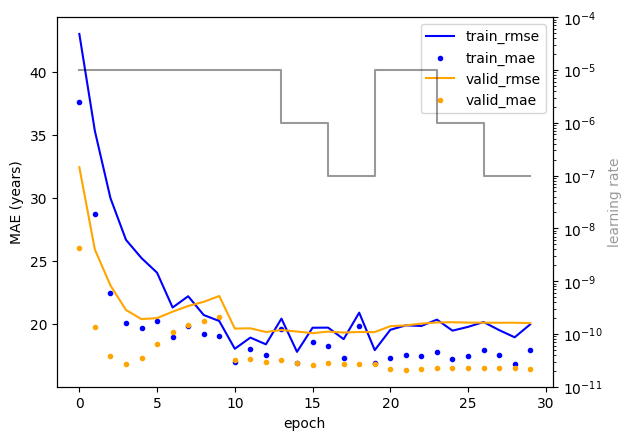

Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [06:49<00:10, 27.76it/s]

Namespace(epochs=10, seed=2, sample_freq=400, seq_length=4096, scale_multiplier=10, batch_size=32, lr=1e-05, patience=2, min_lr=1e-10, lr_factor=0.1, net_filter_size=[64, 128, 196, 256, 320], net_seq_lengh=[4096, 1024, 256, 64, 16], dropout_rate=0.4, kernel_size=17, folder='model/', traces_dset='tracings', ids_dset='', age_col='age', ids_col=None, cuda='1', n_valid=5000, path_to_traces='data/code15-12l/exams_part3.hdf5', path_to_csv='./data/code15-12l/exams_part3.hdf5.csv')
Building data loaders...
Done!
Define model...
Is there an existing trained model? - True
Done!
Define optimizer...
Done!
Define scheduler...
Done!
Training...


Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [07:04<00:10, 27.76it/s]

Epoch  0: 	Train Loss 401.986768 	Train MSE 488.46152 	Train MAE 19.98176
		Valid Loss 399.854249 	Valid MSE 336.82779 	Valid MAE 15.37951 	Learning Rate 0.0000100	


Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [07:16<00:10, 27.76it/s]

...

Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [08:42<00:10, 27.76it/s]

Epoch  8: 	Train Loss 396.036147 	Train MSE 509.12570 	Train MAE 20.17296
		Valid Loss 398.624399 	Valid MSE 352.56854 	Valid MAE 15.93831 	Learning Rate 0.0000100	


Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [08:54<00:10, 27.76it/s]

Epoch  9: 	Train Loss 393.001860 	Train MSE 501.26550 	Train MAE 19.90434
		Valid Loss 398.271635 	Valid MSE 358.56119 	Valid MAE 15.99788 	Learning Rate 0.0000010	
Done!


<Figure size 640x480 with 0 Axes>

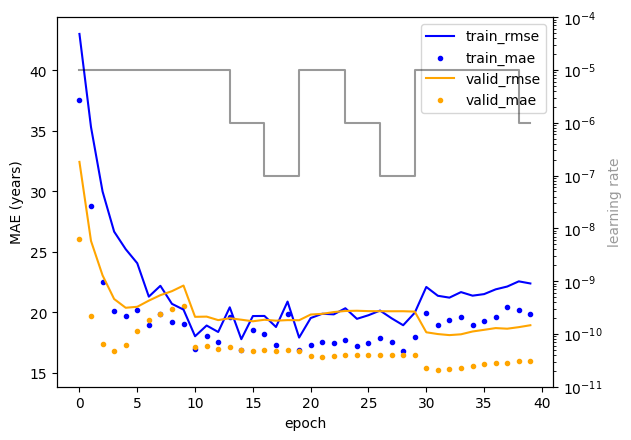

Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [08:54<00:10, 27.76it/s]

Namespace(epochs=10, seed=2, sample_freq=400, seq_length=4096, scale_multiplier=10, batch_size=32, lr=1e-05, patience=2, min_lr=1e-10, lr_factor=0.1, net_filter_size=[64, 128, 196, 256, 320], net_seq_lengh=[4096, 1024, 256, 64, 16], dropout_rate=0.4, kernel_size=17, folder='model/', traces_dset='tracings', ids_dset='', age_col='age', ids_col=None, cuda='1', n_valid=5000, path_to_traces='data/code15-12l/exams_part4.hdf5', path_to_csv='./data/code15-12l/exams_part4.hdf5.csv')
Building data loaders...
Done!
Define model...
Is there an existing trained model? - True
Done!
Define optimizer...
Done!
Define scheduler...
Done!
Training...


Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [09:10<00:10, 27.76it/s]

Epoch  0: 	Train Loss 422.071757 	Train MSE 471.77756 	Train MAE 18.89811
		Valid Loss 391.750633 	Valid MSE 342.49719 	Valid MAE 16.10312 	Learning Rate 0.0000100	


Epoch  0: train - Loss: 384.174676:   3%|▎         | 9/287 [09:22<00:10, 27.76it/s]

Epoch  1: 	Train Loss 423.221027 	Train MSE 506.03864 	Train MAE 19.70041
		Valid Loss 392.858396 	Valid MSE 357.01251 	Valid MAE 16.44075 	Learning Rate 0.0000100	


Epoch  2: train - Loss: 443.693194:  62%|██████▏   | 177/287 [00:06<00:03, 27.89it/s]

In [ ]:
%%time
torch.serialization.add_safe_globals([np.core.multiarray._reconstruct])
for i, H5PATH in enumerate(subsets):
    CSVPATH = f'./data/code15-12l/exams_part{i}.hdf5.csv'
    %run train.py $H5PATH $CSVPATH --epochs 10 --lr 1e-5 --min_lr 1e-10 --patience 2 --n_valid=5000 --dropout_rate 0.4 --cuda 1
    %run plot_learning_curves.py ./model/history.csv